<a href="https://colab.research.google.com/github/AvichalTrivedi7/ANN-Deep-Learning-5th-Semester/blob/main/Lab2_Single_Neuron_Manual.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical 2 - Single Neuron Model (Manual Implementation)

One neuron, built completely by hand - sigmoid activation, the loss function, and the gradient descent update are all derived and coded manually here, no TensorFlow/Keras/sklearn anywhere in this notebook.

**Pipeline:** inputs → weighted sum + bias → sigmoid → loss vs target → gradient (calculus, done by hand) → update weights → repeat.

## How this is different from Practical 1

Practical 1's perceptron used a hard step function and a simple rule - if wrong, nudge the weights toward whatever would've fixed that input (`error = target - prediction`). That works, but there's no actual loss being minimized there and no calculus involved - it's a heuristic, not gradient descent.

A single neuron replaces the hard step with something smooth and differentiable - sigmoid, which means the output is now a probability between 0 and 1 instead of a hard 0/1. Because it's smooth, I can actually define a loss (how wrong the prediction is) and use calculus to work out exactly how much each weight should move to make that loss smaller. That's the real difference: Practical 1 nudges weights on a heuristic, this one moves them by the gradient of an actual loss function. Every deep network beyond this uses the same update rule, just with a lot more neurons and layers stacked on top.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sigmoid activation - squashes any real number into (0, 1)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

class SingleNeuron:
    def __init__(self, input_size, learning_rate=0.5):
        self.weights = np.zeros(input_size)
        self.bias = 0.0
        self.lr = learning_rate

    def forward(self, x):
        z = np.dot(x, self.weights) + self.bias
        return sigmoid(z)

    def predict(self, x, threshold=0.5):
        return 1 if self.forward(x) >= threshold else 0

    def train(self, X, y, epochs=2000):
        loss_history = []
        for epoch in range(epochs):
            total_loss = 0.0
            for xi, target in zip(X, y):
                a = self.forward(xi)
                error = a - target
                total_loss += error ** 2
                # dL/dz = 2*(a - y) * a*(1 - a)   <- chain rule: loss -> sigmoid -> z
                grad_z = 2 * error * a * (1 - a)
                self.weights -= self.lr * grad_z * xi
                self.bias -= self.lr * grad_z
            loss_history.append(total_loss / len(X))
        return loss_history

### In layman terms - where that gradient formula actually comes from

`z` is the exact same weighted sum as Practical 1 (`w·x + b`). The difference starts right after, instead of a hard step, `z` goes through `sigmoid`, which maps any real number into somewhere between 0 and 1. So the neuron's output `a` is now a probability, not a hard decision.

The loss is just `(a - target)^2` - how far off the probability is, squared, so being wrong in either direction is punished, and being *very* wrong is punished a lot more than being a little wrong. To actually reduce that loss, I need to know which direction to push each weight, and that's what the derivative gives me. Going backward through loss → sigmoid → weighted sum (the chain rule):

```
dL/dz = 2*(a - target) * a*(1 - a)
dL/dw = dL/dz * x
dL/db = dL/dz
```

That `a*(1-a)` term is sigmoid's own derivative, it's a big part of *why* sigmoid gets picked for a first example like this, since its derivative is written entirely in terms of its own output, no extra computation needed. Once I have `dL/dz`, the weights just take a small step in the opposite direction (that's the "descent" part of gradient descent), and doing that thousands of times is what actually pulls the loss down.

### Full pipeline

```
Input x = [x1, x2]
        ↓
Weighted sum: z = w1*x1 + w2*x2 + b        (same as Practical 1)
        ↓
Sigmoid: a = 1 / (1 + e^-z)                (new - replaces the step function)
        ↓
Loss: L = (a - target)^2                    (how wrong, squared)
        ↓
Gradient: dL/dz = 2*(a - target)*a*(1-a)    (calculus tells us which way to move)
        ↓
Update: w = w - lr * dL/dz * x
        b = b - lr * dL/dz
        ↓
Repeat for every sample → repeat for many epochs (needs a lot more than Practical 1)
```

## Training on AND, OR and XOR

Same three gates as Practical 1, same 4 input rows, so the two learning rules are directly comparable on identical data. This one needs a lot more epochs than the perceptron did - gradient descent takes small steps, especially once the sigmoid starts saturating near 0 or 1, so this trains for 2000 epochs instead of 10.

In [ ]:
X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
gates = {
    "AND": np.array([0,0,0,1], dtype=float),
    "OR":  np.array([0,1,1,1], dtype=float),
    "XOR": np.array([0,1,1,0], dtype=float),
}

EPOCHS = 2000
results = {}
for name, y_gate in gates.items():
    neuron = SingleNeuron(input_size=2, learning_rate=0.5)
    loss_hist = neuron.train(X, y_gate, epochs=EPOCHS)
    results[name] = (neuron, loss_hist)
    print(f"--- {name} ---")
    print(f"loss @ epoch 1: {loss_hist[0]:.4f}   @ epoch 100: {loss_hist[99]:.4f}   @ epoch {EPOCHS}: {loss_hist[-1]:.5f}")
    for xi, target in zip(X, y_gate):
        prob = neuron.forward(xi)
        print(f"Input: {xi}, Predicted prob: {prob:.4f}, Class: {neuron.predict(xi)}, Actual: {int(target)}")
    print(f"weights: {np.round(neuron.weights,3)}, bias: {neuron.bias:.3f}\n")

--- AND ---
loss @ epoch 1: 0.2682   @ epoch 100: 0.0324   @ epoch 2000: 0.00123
Input: [0. 0.], Predicted prob: 0.0001, Class: 0, Actual: 0
Input: [0. 1.], Predicted prob: 0.0380, Class: 0, Actual: 0
Input: [1. 0.], Predicted prob: 0.0380, Class: 0, Actual: 0
Input: [1. 1.], Predicted prob: 0.9551, Class: 1, Actual: 1
weights: [6.291 6.289], bias: -9.521

--- OR ---
loss @ epoch 1: 0.2359   @ epoch 100: 0.0183   @ epoch 2000: 0.00064
Input: [0. 0.], Predicted prob: 0.0377, Class: 0, Actual: 0
Input: [0. 1.], Predicted prob: 0.9764, Class: 1, Actual: 1
Input: [1. 0.], Predicted prob: 0.9763, Class: 1, Actual: 1
Input: [1. 1.], Predicted prob: 1.0000, Class: 1, Actual: 1
weights: [6.958 6.959], bias: -3.238

--- XOR ---
loss @ epoch 1: 0.2839   @ epoch 100: 0.2842   @ epoch 2000: 0.28422
Input: [0. 0.], Predicted prob: 0.5331, Class: 1, Actual: 0
Input: [0. 1.], Predicted prob: 0.5000, Class: 1, Actual: 1
Input: [1. 0.], Predicted prob: 0.4669, Class: 0, Actual: 1
Input: [1. 1.], Predic

#### Observation
AND and OR both end up extremely confident - predicted probabilities land around 0.0001-0.04 for the 0-class inputs and 0.95-1.0 for the 1-class ones, and the loss for both drops to under 0.002 by epoch 2000. XOR's loss barely moves from where it started (0.284 → 0.284) and its predicted probabilities all hover close to 0.5, the neuron is essentially guessing, and it knows it's guessing.

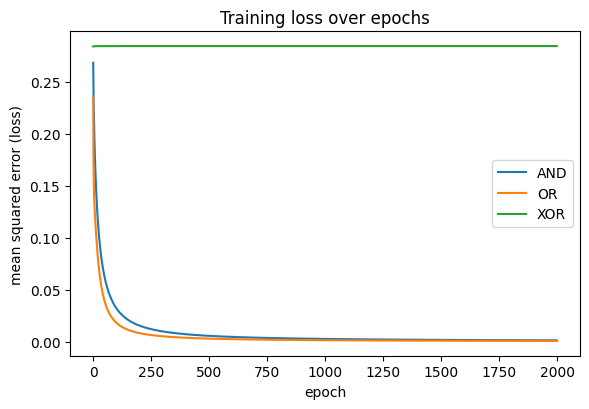

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4.2))
for name in gates:
    _, loss_hist = results[name]
    ax.plot(loss_hist, label=name)
ax.set_xlabel("epoch")
ax.set_ylabel("mean squared error (loss)")
ax.set_title("Training loss over epochs")
ax.legend()
plt.tight_layout()
plt.show()

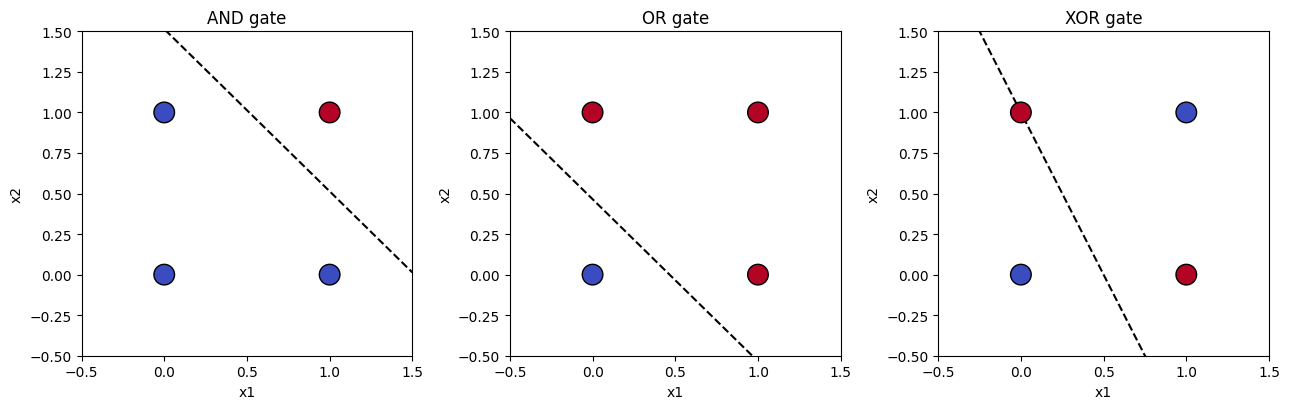

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
xs = np.linspace(-0.5, 1.5, 200)
for ax, name in zip(axes, gates):
    neuron, _ = results[name]
    y_gate = gates[name]
    if abs(neuron.weights[1]) > 1e-9:
        ys = -(neuron.weights[0] * xs + neuron.bias) / neuron.weights[1]
        ax.plot(xs, ys, 'k--', label='decision boundary (p=0.5)')
    elif abs(neuron.weights[0]) > 1e-9:
        ax.axvline(-neuron.bias / neuron.weights[0], color='k', linestyle='--', label='decision boundary (p=0.5)')
    ax.scatter(X[:, 0], X[:, 1], c=y_gate, cmap='coolwarm', s=220, edgecolor='k', zorder=5)
    ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
    ax.set_title(f"{name} gate")
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
plt.tight_layout()
plt.show()

### Personal notes - why XOR still fails here too

This is the part that actually surprised me a little going in - swapping a hard step for a smooth sigmoid and real calculus-based gradient descent feels like a genuine upgrade over Practical 1, so I half expected XOR to work now. It doesn't, and the loss curve shows exactly why, AND and OR both curve smoothly downward, but XOR's line goes flat almost immediately and stays there for the full 2000 epochs. That's not "hasn't converged yet," that's the neuron telling us it already found the best it's capable of.

The reason is that sigmoid only changes *how* the boundary is drawn - soft and probabilistic instead of a hard cutoff, it doesn't change *what shape* the boundary can take. `w1*x1 + w2*x2 + b` is still a straight line (a flat hyperplane in higher dimensions) no matter what gets wrapped around it afterward, and the decision-boundary plot confirms it - the best line this neuron could find for XOR still leaves red and blue points mixed on both sides of it. A single neuron, whatever activation sits on top of it, can only ever cut the input space with one straight line.

So the fix isn't a better activation function or more epochs on this same neuron, it's more neurons. Stack a few of these in a hidden layer and combine their outputs, and the combined boundary can actually bend around a shape like XOR's. That's presumably where the next practical is headed.

#### Summary
- Same weighted sum as Practical 1, but a sigmoid instead of a step function turns the output into a probability, which makes the loss differentiable.
- The gradient (`dL/dz = 2*(a-target)*a*(1-a)`) is derived by hand here with the chain rule, then used to actually run gradient descent - no autograd, no framework.
- AND and OR converge to confidently correct, near-0/near-1 outputs. XOR's loss flatlines almost immediately, because a single neuron can only draw one straight decision boundary no matter what activation sits on top of it.
- Same conclusion as Practical 1, reached through a completely different learning rule: one neuron = one straight line. Bent boundaries need more than one neuron.